In [3]:
!pip install ollama

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [4]:
!pip install numpy pandas

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [1]:
import ollama

In [2]:
def run_prompt_on_image(image_path: str, prompt='', model='ministral-3:3b') -> str:
    """
    Runs a text prompt on an image using Ollama's vision model and returns the response text.
    
    Args:
        image_path (str): Path to the image file (e.g., 'path/to/image.jpg').
        prompt (str): The text prompt to run on the image.
    
    Returns:
        str: The generated text response from the model.
    
    Raises:
        FileNotFoundError: If the image file does not exist.
        Exception: For other Ollama-related errors (e.g., model not available).
    """
    try:
      if prompt is None or prompt.strip() == "":
          prompt = "Describe the image briefly."
        
        # Send the prompt and image to Ollama
      response = ollama.chat(
          model,  # Vision-capable model; ensure it's pulled in Ollama
          messages=[
              {
                  'role': 'user',
                  'content': prompt,
                  'images': [image_path]  # Ollama accepts file paths directly
              }
          ]
      )
      return response['message']['content']
    except FileNotFoundError:
        raise FileNotFoundError(f"Image file not found: {image_path}")
    except Exception as e:
        raise Exception(f"Ollama error: {str(e)}. Ensure Ollama app is running and the model is available.")

In [3]:
image_file = 'frames/bear.jpg'
user_prompt = 'Describe what you see in this image, briefly.'
result = run_prompt_on_image(image_file, user_prompt)
print(result)

In this image, you can see a **brown bear** standing on a rocky surface. The bear appears to be in a natural, forested environment with lush green and autumn-colored foliage in the background. The bear is looking slightly to the side, with a calm and attentive expression.


In [4]:
import numpy as np

def compute_embedding(text: str, model: str = 'embeddinggemma') -> np.ndarray:
    """
    Computes the embedding of a given text string using Ollama's embedding model.
    
    Args:
        text (str): The input text to embed.
        model (str): The Ollama model to use (default: 'embeddinggemma').
    
    Returns:
        np.ndarray: The embedding as a NumPy array of floats.
    
    Raises:
        Exception: For Ollama-related errors (e.g., model not available).
    """
    try:
        response = ollama.embeddings(model=model, prompt=text)
        embedding = response['embedding']  # List of floats
        return np.array(embedding)
    except Exception as e:
        raise Exception(f"Ollama error: {str(e)}. Ensure Ollama app is running and the model is available.")

In [5]:
# Example: Compute embedding for a sample string
sample_text = "Hello, world!"
embedding = compute_embedding(sample_text)
print(f"Embedding shape: {embedding.shape}")
print(f"First 5 values: {embedding[:5]}")

Embedding shape: (768,)
First 5 values: [-0.17776586  0.02132582  0.06748341 -0.03164374  0.02221696]


In [13]:
import pandas as pd
import os

def build_model(image_dir: str = 'frames') -> pd.DataFrame:
    """
    Builds a DataFrame 'model' with columns 'filename', 'description', and 'embedding'
    by processing all .jpg images in the specified directory.
    
    Args:
        image_dir (str): Path to the directory containing .jpg images (default: 'frames').
    
    Returns:
        pd.DataFrame: DataFrame with 'filename', 'description', and 'embedding' columns.
    """
    # Get list of .jpg files in the directory
    image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]
    
    # Initialize list to hold data
    data = []
    
    # Process each image
    for filename in image_files:
        image_path = os.path.join(image_dir, filename)
        # Generate description
        description = run_prompt_on_image(image_path, 'Describe what you see in this image, briefly.')
        # Compute embedding of the description
        embedding = compute_embedding(description)
        # Append to data
        data.append({
            'filename': filename,
            'description': description,
            'embedding': embedding
        })
    
    # Create and return DataFrame
    return pd.DataFrame(data)

# Build the model DataFrame
model_df = build_model('frames')

# Display the DataFrame (first few rows for preview)
print(model_df.head())

         filename                                        description  \
0  frame_0028.jpg  In this image, you can see a kangaroo sitting ...   
1  frame_0162.jpg  In this image, you can see the head and part o...   
2  frame_0128.jpg  In this image, you can see a pink flamingo sta...   
3  frame_0151.jpg  In this image, you can see a horse grazing in ...   
4  frame_0004.jpg  In this image, you can see a vast savanna land...   

                                           embedding  
0  [-0.08300419896841049, -0.04056716710329056, -...  
1  [-0.0615479052066803, 0.06615370512008667, 0.0...  
2  [-0.09118115156888962, -0.018917668610811234, ...  
3  [-0.06069829314947128, 0.010760209523141384, 0...  
4  [-0.059482209384441376, 0.04948760196566582, -...  


In [14]:
import numpy as np

def find_most_similar(model_df: pd.DataFrame, new_embedding: np.ndarray) -> tuple[str, str]:
    """
    Finds the most similar entry in the model DataFrame based on cosine similarity
    with the provided new embedding vector.
    
    Args:
        model_df (pd.DataFrame): The model DataFrame with 'filename', 'description', and 'embedding' columns.
        new_embedding (np.ndarray): The new embedding vector to compare against.
    
    Returns:
        tuple[str, str]: A tuple of (filename, description) for the most similar entry.
    
    Raises:
        ValueError: If the DataFrame is empty or embeddings have mismatched dimensions.
    """
    if model_df.empty:
        raise ValueError("Model DataFrame is empty.")
    
    def cosine_similarity(vec1: np.ndarray, vec2: np.ndarray) -> float:
        dot = np.dot(vec1, vec2)
        norm1 = np.linalg.norm(vec1)
        norm2 = np.linalg.norm(vec2)
        return dot / (norm1 * norm2) if norm1 > 0 and norm2 > 0 else 0.0
    
    # Compute similarities
    similarities = [
        cosine_similarity(new_embedding, emb) for emb in model_df['embedding']
    ]
    
    # Find index of maximum similarity
    max_idx = np.argmax(similarities)
    
    # Return filename and description
    return model_df.iloc[max_idx]['filename'], model_df.iloc[max_idx]['description']

In [8]:
def save_model(model_df: pd.DataFrame, filepath: str) -> None:
    """
    Saves the model DataFrame to a CSV file, serializing the 'embedding' column as strings.
    
    Args:
        model_df (pd.DataFrame): The model DataFrame to save.
        filepath (str): Path to the output CSV file (e.g., 'model.csv').
    """
    df_copy = model_df.copy()
    # Serialize embeddings to comma-separated strings
    df_copy['embedding'] = df_copy['embedding'].apply(lambda x: ','.join(map(str, x)))
    df_copy.to_csv(filepath, index=False)
    print(f"Model saved to {filepath}")

def load_model(filepath: str) -> pd.DataFrame:
    """
    Loads the model DataFrame from a CSV file, deserializing the 'embedding' column back to NumPy arrays.
    
    Args:
        filepath (str): Path to the input CSV file (e.g., 'model.csv').
    
    Returns:
        pd.DataFrame: The loaded model DataFrame.
    
    Raises:
        FileNotFoundError: If the file does not exist.
    """
    df = pd.read_csv(filepath)
    # Deserialize embeddings back to NumPy arrays
    df['embedding'] = df['embedding'].apply(lambda x: np.array([float(i) for i in x.split(',')]))
    print(f"Model loaded from {filepath}")
    return df

In [15]:
# Example: Save and load the model
save_model(model_df, 'model.csv')
loaded_model = load_model('model.csv')
print(loaded_model.head())

Model saved to model.csv
Model loaded from model.csv
         filename                                        description  \
0  frame_0028.jpg  In this image, you can see a kangaroo sitting ...   
1  frame_0162.jpg  In this image, you can see the head and part o...   
2  frame_0128.jpg  In this image, you can see a pink flamingo sta...   
3  frame_0151.jpg  In this image, you can see a horse grazing in ...   
4  frame_0004.jpg  In this image, you can see a vast savanna land...   

                                           embedding  
0  [-0.08300419896841049, -0.04056716710329056, -...  
1  [-0.0615479052066803, 0.06615370512008667, 0.0...  
2  [-0.09118115156888962, -0.018917668610811234, ...  
3  [-0.06069829314947128, 0.010760209523141384, 0...  
4  [-0.059482209384441376, 0.04948760196566582, -...  


In [16]:
from IPython.display import Image, display

def show_image(filename: str, image_dir: str = 'frames') -> None:
    """
    Displays the image in the Jupyter notebook.
    
    Args:
        filename (str): The filename of the image (e.g., 'bear.jpg').
        image_dir (str): The directory containing the image (default: 'frames').
    """
    image_path = os.path.join(image_dir, filename)
    if os.path.exists(image_path):
        display(Image(image_path))
    else:
        print(f"Image not found: {image_path}")

Most similar: frame_0047.jpg - In this image, you can see two vibrant parrot-like birds perched on a branch.

They have striking, vivid plumage:
- Bright red heads and upper chest areas,
- Yellow underbellies and chest regions,
- Dark blue or black wings and tail feathers,
- Some intricate patterns and markings on their feathers.

The birds appear to be in a natural, forested environment, with lush green foliage in the background.


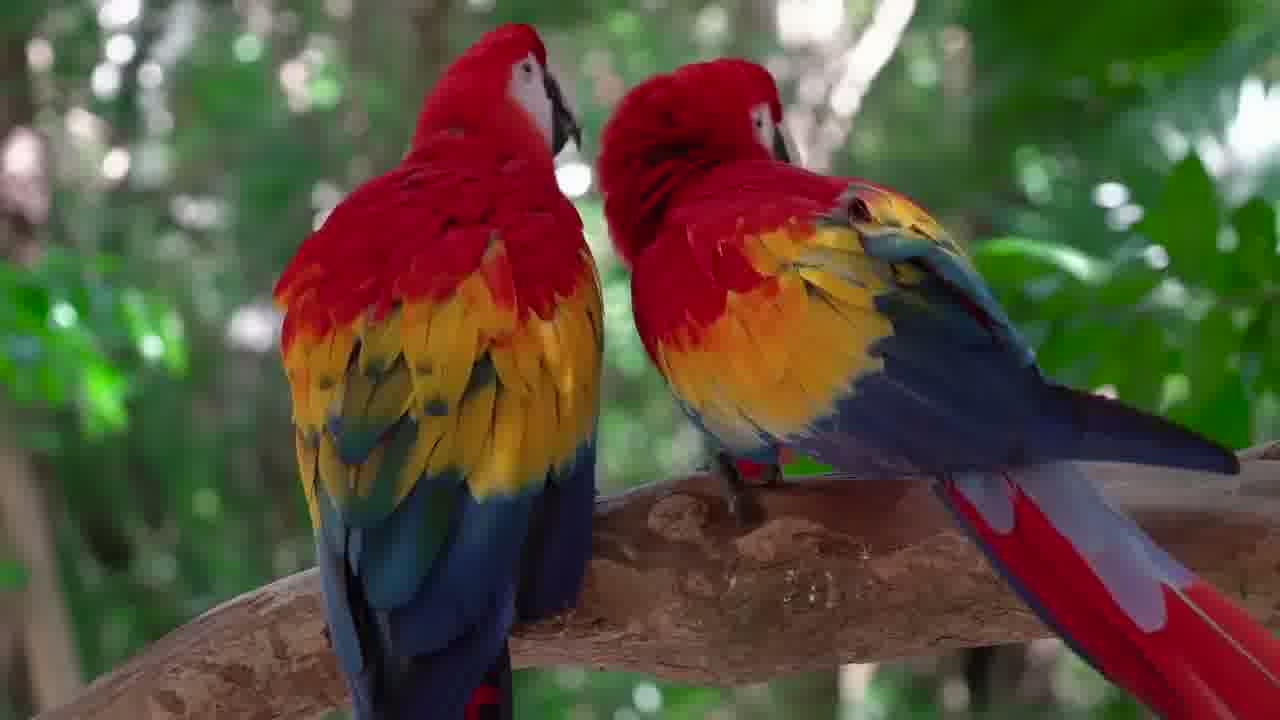

In [19]:
# Example: Find most similar to a new embedding (e.g., from a query string)
query_text = "Show me birds from Amazon."
query_embedding = compute_embedding(query_text)
similar_filename, similar_description = find_most_similar(loaded_model, query_embedding)
print(f"Most similar: {similar_filename} - {similar_description}")

show_image(similar_filename,'frames')